# Baselines on the synthetic testbed

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "sampler_research" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "sampler_research" / "src").exists():
            PROJECT_ROOT = parent
            break

sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))

from sampler_research.io import load_sampler_arrays
from sampler_research import baselines as bl
from sampler_research.graph import grid_edges_8

OUTPUT_DATA_DIR = PROJECT_ROOT / "outputs" / "data"
SEED = 0
ALPHAS = (0.5, 0.25)  # variance-scaling factors for the variance-scaled baseline; matches scripts/run_baselines.py

## Load the toy dataset

In [2]:
TOYS = {
    "random-π (homoscedastic)": "phase_1_homoscedastic",
}

data = {}
for label, stem in TOYS.items():
    d = load_sampler_arrays(OUTPUT_DATA_DIR / f"{stem}.npz")
    data[label] = d
    print(f"{label:32s} pi{d['pi'].shape} mu{d['mu'].shape} sigma{d['sigma'].shape}")


random-π (homoscedastic)         pi(8, 8, 4) mu(8, 8, 4) sigma(8, 8, 4)


## Build every baseline field, per toy

In [3]:
EDGES = grid_edges_8(8, 8)

def build_baselines(d, seed=SEED, alphas=ALPHAS):
    pi, mu, sigma = d["pi"], d["mu"], d["sigma"]
    rng = np.random.default_rng(seed)
    fields = {}
    fields["iid"], _ = bl.iid_baseline(pi, mu, sigma, rng)
    fields["per-cell mode"], _ = bl.mode_field(pi, mu, sigma)
    fields["mixture mean"] = bl.mixture_mean_field(pi, mu)
    for alpha in alphas:
        fields[f"var-scaled (a={alpha:g})"], _ = bl.variance_scaled_baseline(pi, mu, sigma, alpha, rng)
    fields["smoothed-MAP"] = bl.smoothed_map_baseline(pi, mu, sigma)
    fields["a* (smoothest valid)"], _ = bl.smoothest_mode_assignment(pi, mu)
    return fields

baselines = {label: build_baselines(d) for label, d in data.items()}
scores = {
    label: {name: bl.score_field(f, d["pi"], d["mu"], d["sigma"], EDGES)
            for name, f in baselines[label].items()}
    for label, d in data.items()
}

## Field maps

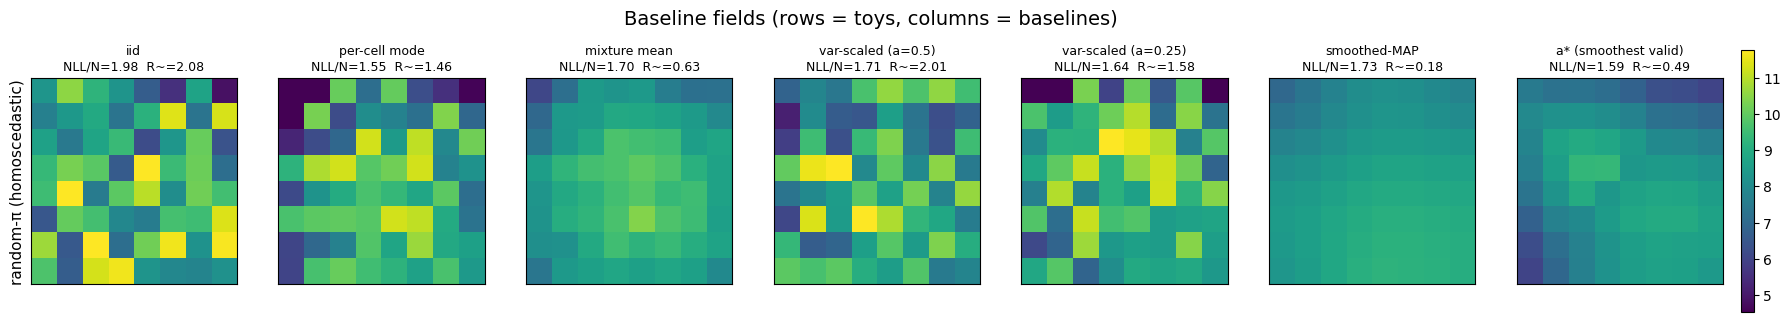

In [4]:
n_cols = max(len(fields) for fields in baselines.values())
fig, axes = plt.subplots(len(baselines), n_cols, figsize=(3.2 * n_cols, 3.4 * len(baselines)))
axes = np.atleast_2d(axes)
for row, (toy_label, fields) in enumerate(baselines.items()):
    stacked = np.concatenate([f.reshape(-1) for f in fields.values()])
    vmin, vmax = np.percentile(stacked, [1, 99])
    for col, (name, field) in enumerate(fields.items()):
        ax = axes[row, col]
        im = ax.imshow(field, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
        s = scores[toy_label][name]
        ax.set_title(f"{name}\nNLL/N={s['nll_over_n']:.2f}  R~={s['r_tilde']:.2f}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(toy_label, fontsize=11)
    fig.colorbar(im, ax=axes[row, :].tolist(), fraction=0.015, pad=0.01)
fig.suptitle("Baseline fields (rows = toys, columns = baselines)", y=1.0, fontsize=14)
plt.show()

## The baseline plane: `NLL/N` vs scale-free `R̃`

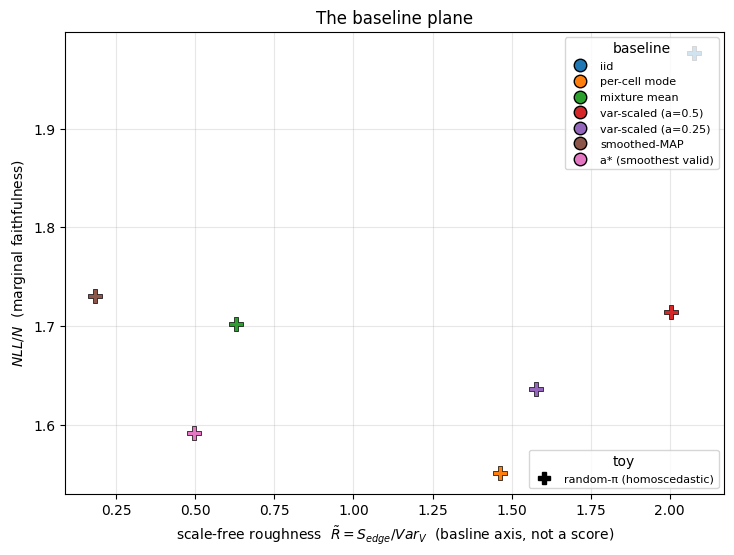

In [5]:
markers = {
    "random-π (homoscedastic)": "P",
}
colors = dict(zip(baselines[next(iter(baselines))], plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(8.5, 6))
for toy_label, per_name in scores.items():
    for name, s in per_name.items():
        ax.scatter(s["r_tilde"], s["nll_over_n"], marker=markers[toy_label],
                   color=colors[name], s=90, edgecolor="k", linewidth=0.5, zorder=3)
        if s["variance_collapsed"]:
            ax.scatter(s["r_tilde"], s["nll_over_n"], marker="o", s=320,
                       facecolor="none", edgecolor="red", linewidth=1.5, zorder=2)

# legends: colour = baseline, marker = toy
from matplotlib.lines import Line2D
baseline_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                           markeredgecolor="k", markersize=9, label=n) for n, c in colors.items()]
toy_handles = [Line2D([0], [0], marker=m, color="k", linestyle="none", markersize=9, label=t)
               for t, m in markers.items()]
leg1 = ax.legend(handles=baseline_handles, title="baseline", loc="upper right", fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=toy_handles, title="toy", loc="lower right", fontsize=8)

ax.set_xlabel(r"scale-free roughness  $\tilde{R} = S_{edge}/Var_V$  (basline axis, not a score)")
ax.set_ylabel(r"$NLL/N$  (marginal faithfulness)")
ax.set_title("The baseline plane")
ax.grid(True, alpha=0.3)
plt.show()


## Scores table

In [6]:
header = (
    f"{'toy':24s} {'baseline':22s} {'NLL/N':>8s} {'R~':>8s} "
    f"{'HF':>8s} {'slope':>8s} {'mono':>6s} {'collapsed':>10s}"
)
print(header)
print("-" * len(header))
for toy_label, per_name in scores.items():
    for name, s in per_name.items():
        slope = "nan" if not np.isfinite(s["spectral_slope"]) else f"{s['spectral_slope']:8.3f}"
        mono = "nan" if not np.isfinite(s["spectral_monotone_fraction"]) else f"{s['spectral_monotone_fraction']:6.3f}"
        print(
            f"{toy_label:24s} {name:22s} {s['nll_over_n']:8.3f} {s['r_tilde']:8.3f} "
            f"{s['spectral_hf_ratio']:8.3f} {slope} {mono} {str(s['variance_collapsed']):>10s}"
        )

toy                      baseline                  NLL/N       R~       HF    slope   mono  collapsed
-----------------------------------------------------------------------------------------------------
random-π (homoscedastic) iid                       1.977    2.077    0.762    0.157  0.667      False
random-π (homoscedastic) per-cell mode             1.551    1.462    0.479   -0.678  0.333      False
random-π (homoscedastic) mixture mean              1.702    0.628    0.107   -2.018  1.000      False
random-π (homoscedastic) var-scaled (a=0.5)        1.714    2.006    0.658   -0.084  0.333      False
random-π (homoscedastic) var-scaled (a=0.25)       1.636    1.576    0.608   -0.398  0.333      False
random-π (homoscedastic) smoothed-MAP              1.730    0.184    0.097   -4.529  1.000      False
random-π (homoscedastic) a* (smoothest valid)      1.591    0.495    0.174   -2.037  1.000      False
